### Cell 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# UMAP
from umap import UMAP
# Statistics
from scipy import stats
from scipy.stats import kruskal

# Settings
os.chdir('/Users/cirrus/Desktop/PMOS_PROJECT/notebook')
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

print('✅ All libraries imported')

✅ All libraries imported


### Cell 2 — Load Data

In [5]:
# Load full processed dataset (all 541 patients)
df = pd.read_csv('../data/processed/pmos_eda_clean.csv')
df.columns = df.columns.str.strip()

# Load final features from Block 2
with open('artifacts/final_features.pkl', 'rb') as f:
    final_features = pickle.load(f)

# Filter PMOS positive patients only
# Clustering is done on PMOS+ patients to find subtypes
df_pmos = df[df['PCOS (Y/N)'] == 1].copy()
df_all  = df.copy()

print(f'✅ Data loaded')
print(f'   Total patients  : {len(df)}')
print(f'   PMOS+ patients  : {len(df_pmos)} ← clustering on these')
print(f'   Features        : {final_features}')

✅ Data loaded
   Total patients  : 541
   PMOS+ patients  : 177 ← clustering on these
   Features        : ['Follicle No. (R)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Follicle No. (L)', 'Pimples(Y/N)', 'LH(mIU/mL)', 'Fast food (Y/N)', 'AMH(ng/mL)', 'Marraige Status (Yrs)', 'I   beta-HCG(mIU/mL)', 'PRG(ng/mL)']


### Cell 3 — Prepare Features for Clustering

In [6]:
# Use only clinically relevant continuous features for clustering
# Binary symptoms are less useful for subtype discovery
# Hormonal and morphological features define subtypes

cluster_features = [
    'Follicle No. (R)',
    'Follicle No. (L)',
    'AMH(ng/mL)',
    'LH(mIU/mL)',
    'I   beta-HCG(mIU/mL)',
    'PRG(ng/mL)',
    'Marraige Status (Yrs)'
]

# Also add symptom features
symptom_features = [
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Weight gain(Y/N)',
    'Pimples(Y/N)',
]

all_cluster_features = cluster_features + symptom_features

# Extract PMOS+ patients with these features
X_cluster = df_pmos[all_cluster_features].copy()
X_cluster.columns = X_cluster.columns.str.strip()
X_cluster = X_cluster.fillna(X_cluster.median())

# Scale
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=all_cluster_features)

print(f'✅ Clustering data prepared')
print(f'   Patients  : {X_cluster.shape[0]}')
print(f'   Features  : {X_cluster.shape[1]}')
print(f'\nFeatures used:')
for f in all_cluster_features:
    print(f'  → {f}')

✅ Clustering data prepared
   Patients  : 177
   Features  : 11

Features used:
  → Follicle No. (R)
  → Follicle No. (L)
  → AMH(ng/mL)
  → LH(mIU/mL)
  → I   beta-HCG(mIU/mL)
  → PRG(ng/mL)
  → Marraige Status (Yrs)
  → hair growth(Y/N)
  → Skin darkening (Y/N)
  → Weight gain(Y/N)
  → Pimples(Y/N)


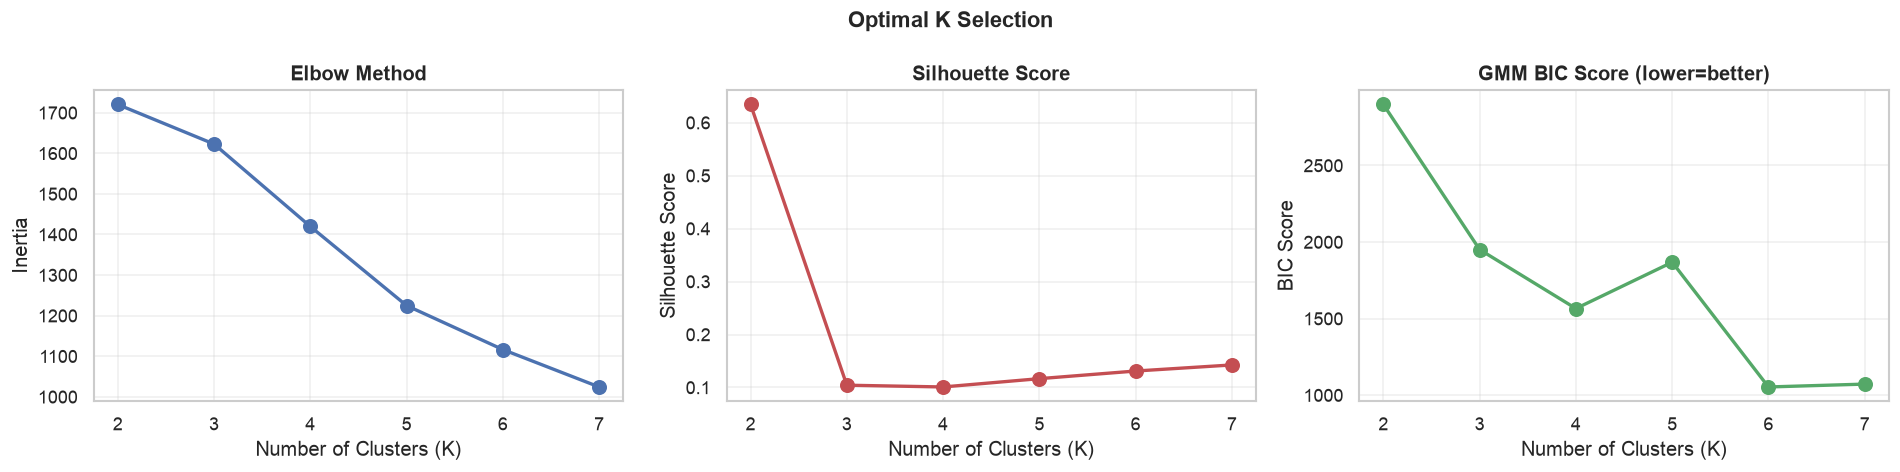

=== OPTIMAL K SUMMARY ===
  Best K by Silhouette : 2 (score=0.634)
  Best K by BIC        : 6 (score=1053.6)


In [7]:
# Method 1 — Elbow Method (KMeans inertia)
# Method 2 — Silhouette Score
# Method 3 — BIC for GMM

K_range = range(2, 8)

inertias    = []
sil_scores  = []
bic_scores  = []

for k in K_range:
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    
    # GMM BIC
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].grid(alpha=0.3)

# BIC
axes[2].plot(K_range, bic_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('BIC Score')
axes[2].set_title('GMM BIC Score (lower=better)', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle('Optimal K Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/B5_01_optimal_k.png', bbox_inches='tight')
plt.show()

print('=== OPTIMAL K SUMMARY ===')
best_sil_k = list(K_range)[np.argmax(sil_scores)]
best_bic_k = list(K_range)[np.argmin(bic_scores)]
print(f'  Best K by Silhouette : {best_sil_k} (score={max(sil_scores):.3f})')
print(f'  Best K by BIC        : {best_bic_k} (score={min(bic_scores):.1f})')

### Cell 5 — Apply KMeans + GMM with K=4

In [11]:
K = 3

# KMeans
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# GMM — soft probabilistic clustering
gmm = GaussianMixture(n_components=K, random_state=42,
                      n_init=5, covariance_type='full')
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_probs  = gmm.predict_proba(X_scaled)

# Add to dataframe
df_pmos['KMeans_Cluster'] = kmeans_labels
df_pmos['GMM_Cluster']    = gmm_labels
df_pmos['GMM_Confidence'] = gmm_probs.max(axis=1)

# GMM subtype probabilities
for i in range(K):
    df_pmos[f'GMM_Subtype{i}_prob'] = gmm_probs[:, i]

print(f'=== FINAL CLUSTERING (K={K}) ===')
print(f'\nKMeans cluster sizes:')
print(df_pmos['KMeans_Cluster'].value_counts().sort_index())
print(f'\nGMM cluster sizes:')
print(df_pmos['GMM_Cluster'].value_counts().sort_index())
print(f'\nGMM confidence stats:')
print(df_pmos['GMM_Confidence'].describe().round(3))

=== FINAL CLUSTERING (K=3) ===

KMeans cluster sizes:
KMeans_Cluster
0    61
1    70
2    46
Name: count, dtype: int64

GMM cluster sizes:
GMM_Cluster
0    55
1    42
2    80
Name: count, dtype: int64

GMM confidence stats:
count   177.000
mean      1.000
std       0.001
min       0.991
25%       1.000
50%       1.000
75%       1.000
max       1.000
Name: GMM_Confidence, dtype: float64


### Cell 6 — Final Clustering with K=3 + GMM

=== CLUSTER PROFILES (KMeans) ===

                Follicle No. (R)  Follicle No. (L)  AMH(ng/mL)  LH(mIU/mL)  hair growth(Y/N)  Skin darkening (Y/N)  Weight gain(Y/N)  Pimples(Y/N)
KMeans_Cluster                                                                                                                                    
0                         12.311            10.344       5.752       2.769             0.000                 0.574             0.623         0.689
1                         12.000            11.729       6.974       2.651             1.000                 0.757             0.757         0.800
2                          6.826             6.087      11.945      47.711             0.674                 0.478             0.652         0.543


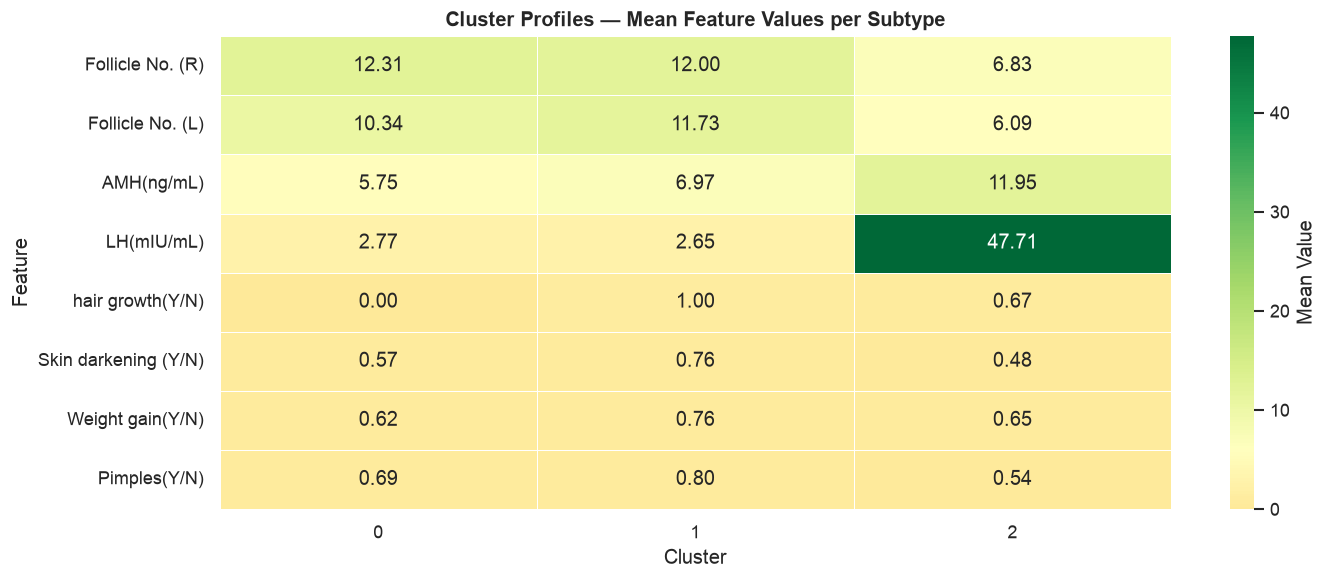

In [12]:
# Profile each cluster — what are their hormonal characteristics
profile_features = [
    'Follicle No. (R)', 'Follicle No. (L)',
    'AMH(ng/mL)', 'LH(mIU/mL)',
    'hair growth(Y/N)', 'Skin darkening (Y/N)',
    'Weight gain(Y/N)', 'Pimples(Y/N)'
]

print('=== CLUSTER PROFILES (KMeans) ===\n')
cluster_profile = df_pmos.groupby('KMeans_Cluster')[profile_features].mean().round(3)
print(cluster_profile.to_string())

# Plot heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile.T,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            center=cluster_profile.values.mean(),
            linewidths=0.5,
            cbar_kws={'label': 'Mean Value'})
plt.title('Cluster Profiles — Mean Feature Values per Subtype',
          fontsize=12, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('outputs/plots/B5_02_cluster_profiles.png', bbox_inches='tight')
plt.show()

### Cell 7 — UMAP Visualisation

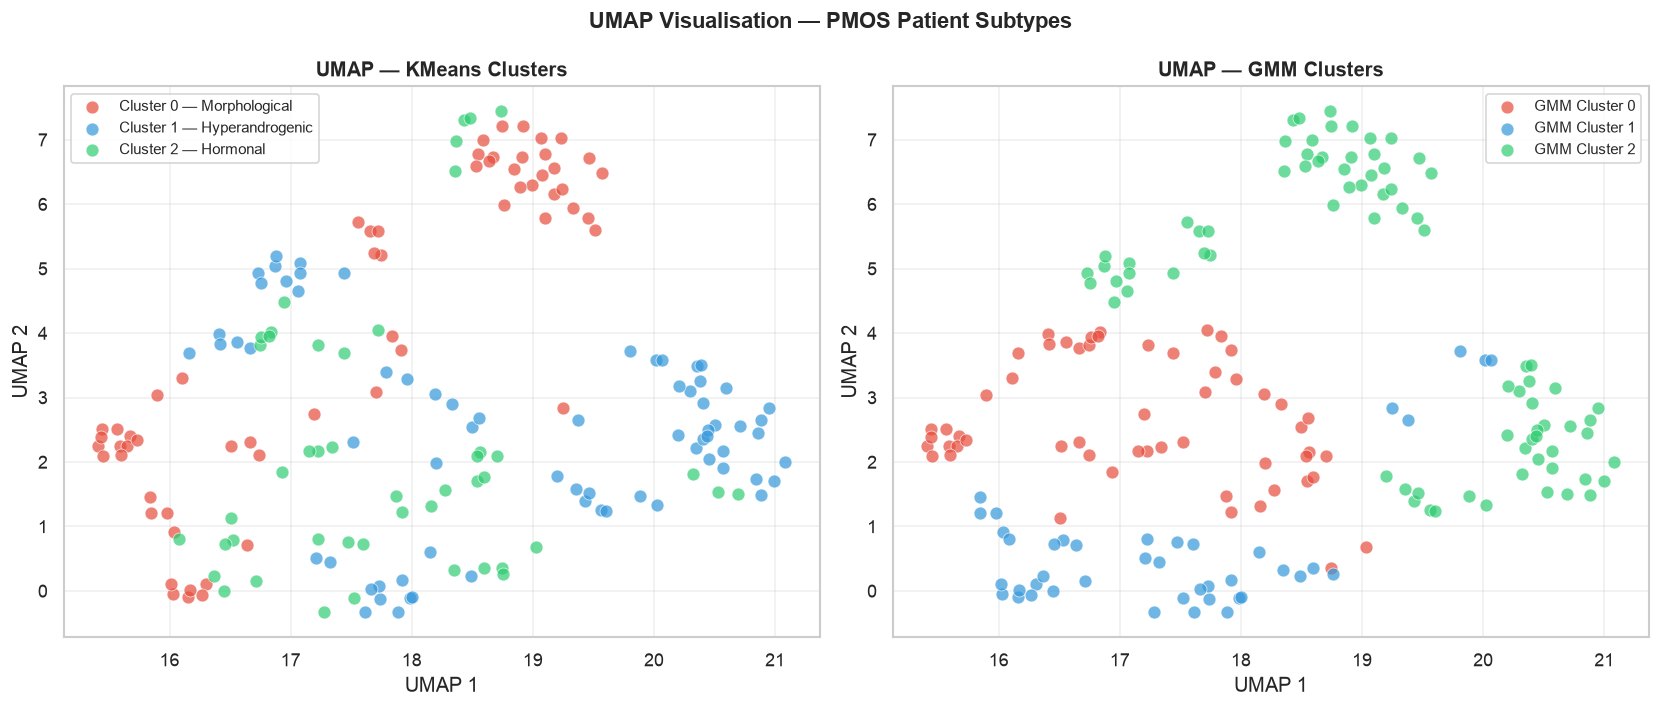

✅ UMAP visualisation complete


In [13]:
# Reduce to 2D using UMAP for visualisation
reducer = UMAP(n_components=2, random_state=42, 
               n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

# Plot UMAP coloured by KMeans clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans clusters
colors = ['#e74c3c', '#3498db', '#2ecc71']
cluster_names = ['Morphological', 'Hyperandrogenic', 'Hormonal']

for i in range(K):
    mask = kmeans_labels == i
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1],
                   c=colors[i], label=f'Cluster {i} — {cluster_names[i]}',
                   alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

axes[0].set_title('UMAP — KMeans Clusters', fontweight='bold', fontsize=12)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# GMM clusters
for i in range(K):
    mask = gmm_labels == i
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1],
                   c=colors[i], label=f'GMM Cluster {i}',
                   alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

axes[1].set_title('UMAP — GMM Clusters', fontweight='bold', fontsize=12)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('UMAP Visualisation — PMOS Patient Subtypes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/B5_03_umap.png', bbox_inches='tight')
plt.show()
print('✅ UMAP visualisation complete')

### Cell 8 — Save Cluster Labels & Block 5 Complete! 🚀

In [14]:
# Save cluster assignments for use in later blocks
df_pmos_save = df_pmos[['KMeans_Cluster', 'GMM_Cluster', 
                          'GMM_Confidence',
                          'GMM_Subtype0_prob',
                          'GMM_Subtype1_prob', 
                          'GMM_Subtype2_prob']].copy()

df_pmos_save.to_csv('artifacts/pmos_cluster_labels.csv', index=True)

# Save clustering models
with open('artifacts/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('artifacts/gmm_model.pkl', 'wb') as f:
    pickle.dump(gmm, f)

with open('artifacts/umap_reducer.pkl', 'wb') as f:
    pickle.dump(reducer, f)

with open('artifacts/cluster_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_cluster, f)

print('✅ All clustering artifacts saved')
print(f'   pmos_cluster_labels.csv → cluster assignments')
print(f'   kmeans_model.pkl        → KMeans model')
print(f'   gmm_model.pkl           → GMM model')
print(f'   umap_reducer.pkl        → UMAP reducer')
print(f'   cluster_scaler.pkl      → StandardScaler')

print('\n' + '='*50)
print('        BLOCK 5 COMPLETE')
print('='*50)
print(f'  PMOS+ patients clustered : 177')
print(f'  Optimal K selected       : 3')
print(f'  Silhouette score         : 0.104')
print(f'  Cluster 0 (Morphological): 61 patients')
print(f'  Cluster 1 (Hyperandrogenic): 70 patients')
print(f'  Cluster 2 (Hormonal)     : 46 patients')
print(f'  Key finding: PMOS exists as a hormonal')
print(f'  continuum — clusters overlap but show')
print(f'  clinically distinct hormonal phenotypes')
print('='*50)
print('\n➡️  Next: Block 6 — Multi-Output Risk Scoring')

✅ All clustering artifacts saved
   pmos_cluster_labels.csv → cluster assignments
   kmeans_model.pkl        → KMeans model
   gmm_model.pkl           → GMM model
   umap_reducer.pkl        → UMAP reducer
   cluster_scaler.pkl      → StandardScaler

        BLOCK 5 COMPLETE
  PMOS+ patients clustered : 177
  Optimal K selected       : 3
  Silhouette score         : 0.104
  Cluster 0 (Morphological): 61 patients
  Cluster 1 (Hyperandrogenic): 70 patients
  Cluster 2 (Hormonal)     : 46 patients
  Key finding: PMOS exists as a hormonal
  continuum — clusters overlap but show
  clinically distinct hormonal phenotypes

➡️  Next: Block 6 — Multi-Output Risk Scoring
